In [26]:
try:
    import pytorch
except ImportError:
    !pip3 install torch torchvision
    #pip3 install --pre torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/nightly/cpu
    pass

try:
    from torchsummary import summary
except ImportError:
    !pip3 install torchsummary
    from torchsummary import summary
    pass

import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import PIL
from torch.utils.data import random_split
from torch.utils.data import Dataset
import zipfile
import os
import urllib
import tarfile

In [27]:
BATCH_SIZE = 128
TEST_SPLIT = 0.1
VAL_SPLIT = 0.15

USE_WEIGHTS = False
LEARN_RATE = 0.001
OUTPUT_CLASSES = 10
HIDDEN_UNITS = 512
DIM_X = 180
DIM_Y = 180
CHANNELS = 3
PIN=False

# This one is pretty fast, so you can crank this up if you have time
EPOCHS = 5

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA device found.", torch.cuda.is_available())
    BATCH_SIZE = 1024
    EPOCHS = EPOCHS*3
    PIN = True
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print ("MPS device found.", torch.backends.mps.is_available())
    BATCH_SIZE = 256
    EPOCHS = EPOCHS*2
else:
    device = torch.device("cpu")
    print ("MPS/GPU device not found.")
    BATCH_SIZE = 256
    EPOCHS = 10

print(f"Using device: {device}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")

CUDA device found. True
Using device: cuda
Batch size: 1024
Epochs: 15


In [28]:
def downloadDataset(url: str, destination: str) -> str:
    os.makedirs(destination, exist_ok=True)
    
    # Determine the filename from the URL
    file_name = url.split("/")[-1]
    file_path = os.path.join(destination, file_name)
    
    # Download the file
    if not os.path.exists(file_path):
        print(f"Downloading {url}...")
        urllib.request.urlretrieve(url, file_path)
        print(f"Downloaded to {file_path}")
    else:
        print(f"File already exists at {file_path}, skipping download.")
    
    # Extract if it's a tar/tgz/tar.gz file
    if file_path.endswith((".tgz", ".tar.gz", ".tar")):
        print(f"Extracting {file_path}...")
        with tarfile.open(file_path, "r:*") as tar:
            tar.extractall(path=destination)
        print(f"Extracted to {destination}")
    # Extract if it's a zip file
    elif file_path.endswith(".zip"):
        print(f"Extracting {file_path}...")
        with zipfile.ZipFile(file_path, "r") as zip_ref:
            zip_ref.extractall(destination)
        print(f"Extracted to {destination}")
    else:
        print("No extraction needed.")
    
    # Delete the archive file after extraction
    if file_path.endswith((".tgz", ".tar.gz", ".tar", ".zip")):
        print(f"Removing archive {file_path}...")
        os.remove(file_path)
        print(f"Removed {file_path}")
    # Find the extracted directory
    extracted_dirs = [d for d in os.listdir(destination) if os.path.isdir(os.path.join(destination, d))]
    if extracted_dirs:
        return os.path.join(destination, extracted_dirs[0])
    return file_path

dataset_url = dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
destination = "data/flowers"

flower_path = downloadDataset(dataset_url, destination)
print(flower_path)

Downloaded to data/flowers/flower_photos.tgz
Extracting data/flowers/flower_photos.tgz...


/tmp/ipykernel_1800/154362911.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=destination)


Extracted to data/flowers
Removing archive data/flowers/flower_photos.tgz...
Removed data/flowers/flower_photos.tgz
data/flowers/flower_photos


In [29]:
class FlowerDataset(Dataset):
    def __init__(self, root_path, transform=None):
        self.path = root_path
        self.transform = transform
        self.image_paths = []
        self.labels = []
        print(f"Loading dataset from {self.path}...")
        for label in os.listdir(self.path):
            label_folder = os.path.join(self.path, label)
            if os.path.isdir(label_folder):
                for img_file in os.listdir(label_folder):
                    if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                        self.image_paths.append(os.path.join(label_folder, img_file))
                        self.labels.append(label)
        self.label_to_index = {label: idx for idx, label in enumerate(set(self.labels))}
        self.index_to_label = {idx: label for label, idx in self.label_to_index.items()}
        self.labels = [self.label_to_index[label] for label in self.labels]
        print(f"Found {len(self.image_paths)} images across {len(self.label_to_index)} classes.")
        print(f"Class to Index Mapping: {self.label_to_index}")

    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        # Force all images to 3 channels for ResNet
        image = PIL.Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)
        return image, label
    def get_labels(self):
        #return self.labels
        return self.index_to_label

model_list = {}

# Transfer Learning

Transfer learning involves taking a smart model, generally one trained on a large dataset, and repurposing it for a different task. This is often done by taking the pretrained model, removing the final classification layers, and attaching new fully connected layers that are setup for our new data. We then have the option to either freeze the pretrained layers and only train the new layers, or to fine-tune the entire model by allowing all layers to be updated during training.

![Transfer Learning](images/transfer_learning.png "Transfer Learning")

With image recognition, the convolutional layers of a pretrained model can be very effective at extracting features from images, as "seeing items" requires mostly the same work no matter what exactly the model is looking at. The final fully-connected layers take what the convolutional layers have extracted and make predictions based on that. We can take a model that is better at extracting features than we can expect to train ourselves, and then add on some layers to turn those features into predictions for our specific task. Recall from the kernels and feature maps, the features that get extracted from the convolutional layers are often things like edges, textures, and shapes. These are useful to predict almost anything. 

## Base Model 

We can download a pretrained model from the PyTorch set of premade models. 

In [30]:
base_model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', weights="ResNet18_Weights.DEFAULT")
MODEL_X = 180
MODEL_Y = 180

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


### Model Specific Data Preparation

One thing to note is that each model expects the data to be in a specific format. This includes the size, the number of channels, and the scale of the pixel values. We need to make sure that we match this to ensure things work and work well. Usually, this is documented in the model's documentation, and we just need to manipulate our data to match it.

It is probably a good idea to choose a model that uses images roughly the size as ours, as that model will probably have an appropriate architecture and capacity, but we don't have to. Resizing the images to match is a distortion, but in most cases we should be ok unless we are really changing the image. 

### Preprocessing Modules

Some models have specific preprocessing steps that they expect. 

In [31]:
preprocess = transforms.Compose([
    transforms.Resize((DIM_X, DIM_Y)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## Prepare Model for Training

To prepare the model for training, we need to do a few things:
<ul>
    <li>Freeze the base model's layers, so they won't be updated during training. </li>
    <li>Replace the fully connected layers, the classifier, with a custom version for us. </li>
    <li>Set the loss function and optimizer</li>
</ul>



In [32]:
base_layers = list(base_model.children())[:-1]
dense_layers = list(base_model.children())[-1:]
print("Base Layers:", base_layers)
print("Dense Layers:", dense_layers)

Base Layers: [Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False), BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True), ReLU(inplace=True), MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False), Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), paddin

### Freeze Base Layers

In [33]:
for param in base_model.parameters():
    param.requires_grad = False

### Create and Add New Classifier

We can now attach a new classifier. The output of the convolutional layers is exactly the same as the original model, we haven't impacted the model's ability to "see". Those features are now fed to our new classifier, which will get trained to make the correct predictions for our data. So the part that is training is learning how to predict our classes, given what the smart model we borrowed from has seen. 

![Transfer Learning](images/transfer_learning_2.png "Transfer Learning")

In [34]:
new_classifier = nn.Sequential(
    nn.Linear(in_features=512, out_features=HIDDEN_UNITS),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(in_features=HIDDEN_UNITS, out_features=OUTPUT_CLASSES)
)
new_model = nn.Sequential(
    *base_layers,
    nn.Flatten(),
    *new_classifier
)
new_model = new_model.to(device)
#summary(new_model, input_size=(CHANNELS, MODEL_X, MODEL_Y))
model_list["New_Classifier"] = new_model

### Prepare Data and Dataloaders

In [35]:
full_dataset = FlowerDataset(root_path="data/flowers/flower_photos/", transform=preprocess)
dataset_size = len(full_dataset)
val_size = int(VAL_SPLIT * dataset_size)
train_size = dataset_size - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=PIN)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


Loading dataset from data/flowers/flower_photos/...
Found 3670 images across 5 classes.
Class to Index Mapping: {'daisy': 0, 'tulips': 1, 'dandelion': 2, 'sunflowers': 3, 'roses': 4}


### Belated Baseline

We can also create a baseline model that is the same architecture as our new model, and see how it performs. This isn't really a 1 to 1 comparison, since we don't really have the same data, which is critical for performance. We'd also really need to train this more than this example here to realistically evaluate it, but let's see how she goes!

In [36]:
baseline_layers = list(base_model.children())[:-1]
new_layers = []
# Create new layer matching the original 
for layer in base_layers:
    if isinstance(layer, nn.Linear):
        new_layers.append(nn.Linear(in_features=layer.in_features, out_features=layer.out_features))
    elif isinstance(layer, nn.Conv2d):
        new_layers.append(nn.Conv2d(in_channels=layer.in_channels, out_channels=layer.out_channels, kernel_size=layer.kernel_size, stride=layer.stride, padding=layer.padding))
    elif isinstance(layer, nn.BatchNorm2d):
        new_layers.append(nn.BatchNorm2d(num_features=layer.num_features))
    elif isinstance(layer, nn.ReLU):
        new_layers.append(nn.ReLU())
    elif isinstance(layer, nn.MaxPool2d):
        new_layers.append(nn.MaxPool2d(kernel_size=layer.kernel_size, stride=layer.stride, padding=layer.padding))
    elif isinstance(layer, nn.AdaptiveAvgPool2d):
        new_layers.append(nn.AdaptiveAvgPool2d(output_size=layer.output_size))
    else:
        new_layers.append(layer)

baseline_classifier = nn.Sequential(
    nn.Linear(in_features=512, out_features=HIDDEN_UNITS),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(in_features=HIDDEN_UNITS, out_features=OUTPUT_CLASSES)
)
baseline_model = nn.Sequential(
    *new_layers,
    nn.Flatten(),
    *baseline_classifier
)

    
baseline_model = baseline_model.to(device)
summary(baseline_model, input_size=(CHANNELS, MODEL_X, MODEL_Y))
model_list["Baseline"] = baseline_model

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 90, 90]           9,472
       BatchNorm2d-2           [-1, 64, 90, 90]             128
              ReLU-3           [-1, 64, 90, 90]               0
         MaxPool2d-4           [-1, 64, 45, 45]               0
            Conv2d-5           [-1, 64, 45, 45]          36,864
       BatchNorm2d-6           [-1, 64, 45, 45]             128
              ReLU-7           [-1, 64, 45, 45]               0
            Conv2d-8           [-1, 64, 45, 45]          36,864
       BatchNorm2d-9           [-1, 64, 45, 45]             128
             ReLU-10           [-1, 64, 45, 45]               0
       BasicBlock-11           [-1, 64, 45, 45]               0
           Conv2d-12           [-1, 64, 45, 45]          36,864
      BatchNorm2d-13           [-1, 64, 45, 45]             128
             ReLU-14           [-1, 64,

## Fine-Tuning

Fine-tuning is the process of unfreezing some or all of the base model's layers and training them along with the new classifier. This allows the model to adjust the features it has learned to better fit our data. Normally, this is done with a lower learning rate, with the intent of slightly adjusting the weights in the direction of our data, not making drastic changes.

To do fine-tuning, we want a model that is already trained - the low learning rate wouldn't allow the classifier part to learn effectively if we started from scratch. For this, we'll use our new model that we just trained, which has a classifier that is already trained to predict our classes. Fine-tuning can also be done on a model as a whole (or layers from it) without the new classifier, or with smaller changes. For example, suppose we had a model that looked at MRI images and predicted if that image is cancerous or not. We could take that model, and fine-tune it to predict some other variety of cancer. 

For our purposes, a frozen base model and a new classifier will likely perform best, for the reason that we don't have the data or resources to train a model that is comparable to how the original ones were trained, so it is unlikely we can better it. The more the tasks diverge, the less true this holds. For general "I see stuff" types of tasks, the convolutional layer performance is likely to do well after we repurpose it to some other generic task. If we are dealing with something like MRI imaging, what the convolutional layers are "seeing" starts to become less similar to "normal" images, so we'd expect that more customization becomes more valuable here. 

![Fine Tune](images/fine_tune.png "Fine Tuning")

## Train Loop

This train loop is pretty simple, the only special thing is that we are capturing the losses and accuracy. 

In [37]:
def trainloop(model, device, train_loader, val_loader, epochs, loss_fn, optimizer):
    ES_EPOCHS = 4
    ES_TOLERANCE = 0.01
    best_val_acc = 0
    best_model_state = None
    stop_count = 0

    model.to(device)
    train_losses = []
    val_losses = []
    val_accuracies = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        with torch.enable_grad():
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(images)
                # Adapt labels for BCEWithLogitsLoss if necessary
                if isinstance(loss_fn, nn.BCEWithLogitsLoss):
                    labels = labels.float().unsqueeze(1)
                loss = loss_fn(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * images.size(0)
            epoch_train_loss = running_loss / len(train_loader.dataset)
            train_losses.append(epoch_train_loss)

        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = loss_fn(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_correct += (predicted == labels).sum().item()
        val_losses.append(val_running_loss / len(val_loader.dataset))
        val_accuracies.append(val_correct / len(val_loader.dataset))
        if val_accuracies[-1] > best_val_acc:
            best_val_acc = val_accuracies[-1]
            best_model_state = model.state_dict().copy()
            stop_count = 0
        else:
            stop_count += 1

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_train_loss:.4f} - Val Loss: {val_losses[-1]:.4f} - Val Accuracy: {val_accuracies[-1]:.4f}")
    return train_losses, val_losses, val_accuracies

In [ ]:
accuracies = {}
train_order = ["Baseline", "New_Classifier", "FineTune_newclassifier"]

for model_name in train_order:
    model = model_list[model_name]
    print(f"Training {model_name}...")
    if model_name == "Baseline":
        loss_fn = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARN_RATE)
        _, __, base_val_acc = trainloop(model, device, train_loader, val_loader, EPOCHS*2, loss_fn, optimizer)
        accuracies[model_name] = base_val_acc
    elif model_name == "FineTune_newclassifier":
        for param in model.parameters():
            param.requires_grad = True

        fine_tune_rate = LEARN_RATE / 100
        fine_tune_loss = nn.CrossEntropyLoss()
        fine_tune_optimizer = torch.optim.Adam(model.parameters(), lr=fine_tune_rate/10)
        _, __, fine_tune_val_acc = trainloop(model, device, train_loader, val_loader, EPOCHS, fine_tune_loss, fine_tune_optimizer)
        accuracies[model_name] = fine_tune_val_acc
    elif model_name == "New_Classifier":
        loss_fn = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARN_RATE/2)
        _, __, other_val_acc = trainloop(model, device, train_loader, val_loader, EPOCHS, loss_fn, optimizer)
        accuracies[model_name] = other_val_acc
        model_list["FineTune_newclassifier"] = model
    else:
        print(f"Unknown model {model_name}, skipping training.")

Training Baseline...
Epoch 1/15 - Train Loss: 0.8035 - Val Loss: 1.2799 - Val Accuracy: 0.5109
Epoch 2/15 - Train Loss: 0.7516 - Val Loss: 1.0388 - Val Accuracy: 0.6127
Epoch 3/15 - Train Loss: 0.6973 - Val Loss: 0.9740 - Val Accuracy: 0.6364
Epoch 4/15 - Train Loss: 0.6736 - Val Loss: 0.8200 - Val Accuracy: 0.6673
Epoch 5/15 - Train Loss: 0.6399 - Val Loss: 0.8219 - Val Accuracy: 0.6782
Epoch 6/15 - Train Loss: 0.5982 - Val Loss: 0.8334 - Val Accuracy: 0.6909
Epoch 7/15 - Train Loss: 0.5906 - Val Loss: 0.8248 - Val Accuracy: 0.6800
Epoch 8/15 - Train Loss: 0.5961 - Val Loss: 0.8246 - Val Accuracy: 0.6927
Epoch 9/15 - Train Loss: 0.5986 - Val Loss: 0.7865 - Val Accuracy: 0.7164
Epoch 10/15 - Train Loss: 0.6099 - Val Loss: 0.7997 - Val Accuracy: 0.7055
Epoch 11/15 - Train Loss: 0.5908 - Val Loss: 0.8096 - Val Accuracy: 0.6945
Epoch 12/15 - Train Loss: 0.5823 - Val Loss: 0.7897 - Val Accuracy: 0.7018
Epoch 13/15 - Train Loss: 0.5716 - Val Loss: 0.8928 - Val Accuracy: 0.6673
Epoch 14/15 -

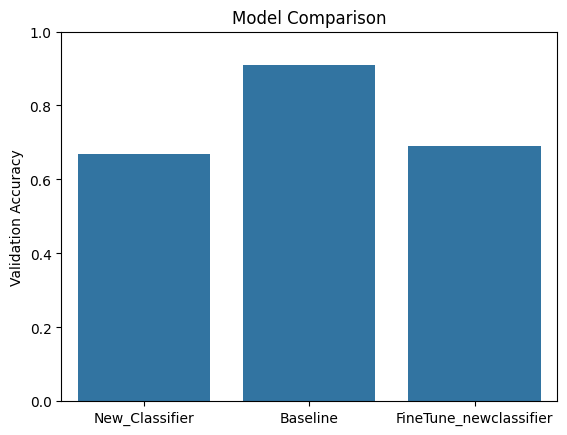

In [ ]:
max_accuracies = {model_name: np.max(acc) for model_name, acc in accuracies.items()}
sns.barplot(x=list(max_accuracies.keys()), y=list(max_accuracies.values()))
plt.ylabel("Validation Accuracy")
plt.title("Model Comparison")
plt.ylim(0, 1)
plt.show()

### Transfer Learning Conclusion

Transfer learning is common, especially when working with things like images. Pretrained models that have seen millions upon millions of images get very good at "understanding" what is in an image, or extracting important features from those images. This basic ability to "see" image data is interchangeable between different types of image tasks that we may want to do. For image data, natural language, audio, video, it is likely that one of these large models will be more capable of extracting features from the data than we could ever hope to do from scratch. Since the basics of "seeing a thing" or "reading a sentence" is the same no matter the specific application, that ability to process the data that our pretrained models have can be repurposed to our specific ends. 

We can see lots of scenarios in the real world where people are adapting image recognition models trained by Google to do things like recognize objects in their home security system, or language models like the GPT family being adapted to better understand domain specific language. We'll likely see more of this, as the benefits of training on massive amounts of data are hard, if not impossible, to replicate. 

## Fine-Tuning and Large Models

One rapidly expanding application of fine-tuning is to customize large models, most notably large language models like ChatGPT. These models are massive, and the training process is incredibly resource intensive - to the point where training a model initially can cost millions of dollars worth or processing time and electricity and require GPUs that are well beyond what is available to a consumer, or at least a consumer who doesn't want to spend $10,000+ on their graphic card. Customizing these types of models is a useful application of fine-tuning, as it is the only realistic approach to repurposing or targeting a model that is too large for us to train from scratch. 

There are several fine-tuning methodologies and processes that are emerging as LLMs become more common, and more are being created all the time. One such approach is LORA - 

### LORA

LORA is an approach to fine-tuning a large model that aims to be more efficient by splitting the weights of the model into two subsets - those that matter (for our purposes) and those that don't, then creating a training process that only modifies the subset of "important" weights. We can think of this with an analogy with different types of speech. For example, if an engineer is speaking about the structural dynamics of a bridge, and a doctor is speaking about treating a patient's cancer, they will each sound very different, even though they are both speaking English. In this example the English part of the model does not change between the two types of speech, but the specific details that make it "engineering-talk" versus "doctor-talk" does change. LORA aims to split the weights into the these two subgroups, one that changes and one that does not; the fine-tuning process then trains only the parts that need to change, resulting in far fewer weights that need to be adjusted and a far less demanding fine-tuning process. This can allow models that are large, advanced, and complex to be fine-tuned to specific applications in less time and potentially even on consumer GPUs, something that is generally not possible with the most advanced models. 

Other fine-tuning approaches do similar-ish things, reduce the amount of work done in the tuning process by only tweaking a minimal subset of weights, instead of all of them. 

### Quantized Models

Quantized models are versions that have been made smaller by reducing the precision of the variables used to store values, making it smaller and compute faster. For example, changing a 32 bit float to a 16 bit float. If you recall the inner operation of a neural network in both passes of operation, there are a very large number of matrix operations, meaning a huge number of multiply, add, and others. The lower precision the values in this calculation are, the less precise our model's 'resolution' can be, but the faster it can be processed. A large model can have millions or billions of parameters, if each one is 32 or 16 bits, that adds up to a lot of memory at some point. Really large models may have tens of gigabytes of weights alone, and this upper limit grows constantly. 

Quantization is commonly seen recently in the distribution of large LLM or other generative models from institutional developers to the public. This includes models you can download from Facebook (llama LLM), Google, or others from places like HuggingFace. Many of these models are very smart, and thus very large - they are often trained on volumes of data that would be impossible for a home user to match. Often these models are also too large to run on commercial equipment, most commonly they couldn't fit on the GPU RAM of consumer graphics cards. For a model to be used, it must be loaded into the GPU's memory, this is what the to(device) command does, a batch of data also needs to be loaded, along with whatever assorted overhead there is to execute this. All of this must add up to take up less memory than the GPU has. To allow some of these very large models to be used on more devices, people publish quantized versions, using lower precision datatypes that take up less memory. These versions get worse overall as they shrink, but they use technique to do the compression that tend to hang on to more than a proportionate amount of performance *per* size lost, leaving a model with lots of the smarts at a lower size. 

There is a good article explaining it here, though the details are not critical to us: https://developer.nvidia.com/blog/model-quantization-concepts-methods-and-why-it-matters/

## Exercise

Make a model, then try to beat it with a transfer learning model. There are many image models that you can download from the pytorch library, the details are here: https://docs.pytorch.org/vision/main/models.html. You can also find models at other places like hugging face if you're feeling wild. Choose one to start with from here. Note that some of the large models may be really big, there's a chart that list each model's size in number of parameters. The ResNet18 in this example has about 11.8 million. 

<b>Note: model performance on this dataset is very good, better than I expected when I grabbed it. Most trials were near 100% on validation after an epoch or two. If you want to jump straight to something with more of a tuning challenge, try the flower dataset of CIFAR10, those will have more errors to try to correct.</b> 

#### Variations to Try

If you're done, make sure that you are ok with a few different concepts that are important for CNNs and models in general:
<ul>
<li> Add tensorboar logging. </li>
<li> Use one of the other datasets, try to adapt your model/data processing to work with it. </li>
<li> Use RayTune to find better hyperparameters. </li>
<li> Visualize some mid-training aspect - show prediction, salience, feature maps, etc... </li>
</ul>

If given an image dataset, we should be able to make a classification model and tune it for basically any image dataset we get. 

In [ ]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("BTX24/PCOS-ultrasound-dataset")
# Prepare ultrasound datasets and dataloaders (using validation naming instead of test)

US_X_DIM = 224
US_Y_DIM = 224
US_CHANNELS = 1

us_transform = transforms.Compose([
    transforms.Resize((US_X_DIM, US_Y_DIM)),
    transforms.ToTensor()
])

class UltrasoundDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.hf_dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, idx):
        sample = self.hf_dataset[idx]
        image = sample["image"]
        label = sample["label"]

        if isinstance(image, torch.Tensor):
            image = transforms.ToPILImage()(image)

        image = image.convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

train_us_dataset = UltrasoundDataset(ds["train"], transform=us_transform)
val_us_dataset = UltrasoundDataset(ds["test"], transform=us_transform)

train_us_loader = DataLoader(
    train_us_dataset,
    batch_size=32,
    shuffle=True,
    pin_memory=PIN
)

val_us_loader = DataLoader(
    val_us_dataset,
    batch_size=32,
    shuffle=False,
    pin_memory=PIN
)

print(f"Train samples: {len(train_us_dataset)}")
print(f"Validation samples: {len(val_us_dataset)}")

KeyboardInterrupt: 

### Image Dataset Processing

This dataset has images that are varying sizes. To manage that we will resize everything to a standard. This is reasonable but not optimal. For this dataset in particular, the correct thing to do is likely to crop the images then resize to a standard. If we wanted to do that in an automated way, there are other branches of image recognition that will allow us to do things like find objects within an image and enclose them with a bounding box. If we had a good object detection model, we could find the interesting part of the image, extract it, then resize to a standard. 

#### Change the Channel

Note that this dataset has 1 channel, while pretrained models expect 3 channels. What can we do to bridge this gap... (it isn't complicated, think about a potential solution then search online to see if what you did was reasonable).

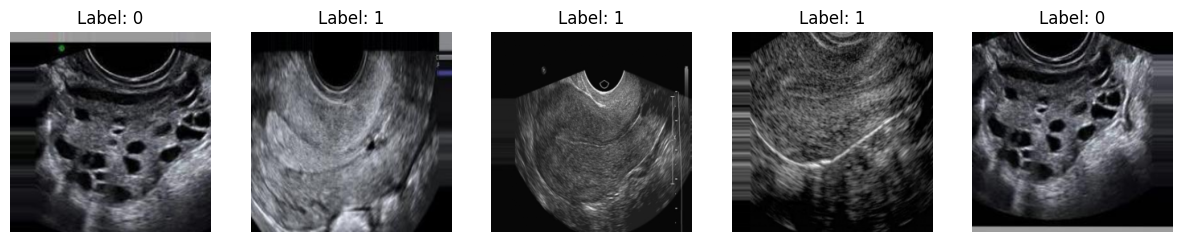

In [ ]:
def PreviewUltrasoundDataset(dataset, num_samples=5):
    plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        image, label = dataset[i]
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(image.permute(1, 2, 0))  # Convert from (C, H, W) to (H, W, C)
        plt.title(f"Label: {label.item()}")
        plt.axis("off")
    plt.show()

PreviewUltrasoundDataset(val_us_dataset, 8)

### Make a (Modifyable) Model 

We can start with a model. In making a model I'm going to keep a few things in mind to allow me to use it later for tuning with RayTune. In this model:
<ul>
<li> Things that can be configured are all controled by the incoming arguments in the constructor. This includes things like the number of layers, the number of neurons in each layer, etc...</li>
<li> Things are setup to adjust based on that - <b>this isn't always trivial</b>. If there are different strides or dilation, this can make having sizes automatically adjust more difficult. </li>
</ul>

Try to make a model that allows for variation in both width and depth, so that you can experiment with both of those things when you get to tuning.

In [ ]:
class UltrasoundModel(nn.Module):
    def __init__(self, numberStacks=3, num_kern_1=64, fc1=1024, fc2=512, output_classes=2, dropout=.3):
        super(UltrasoundModel, self).__init__()
        for i in range(numberStacks):
            conv_layer = nn.Conv2d(in_channels=3 if i == 0 else num_kern_1*(2**(i-1)), 
                                   out_channels=num_kern_1*(2**i), 
                                   kernel_size=3, 
                                   stride=1, 
                                   padding=1)
            setattr(self, f"conv_{i+1}", conv_layer)
            setattr(self, f"relu_{i+1}", nn.ReLU())
            setattr(self, f"pool_{i+1}", nn.MaxPool2d(kernel_size=2, stride=2))
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(num_kern_1*(2**(numberStacks-1)) * (US_X_DIM // (2**numberStacks)) * (US_Y_DIM // (2**numberStacks)), fc1)
        self.relu_fc1 = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(fc1, fc2)
        self.relu_fc2 = nn.ReLU()
        self.output_layer = nn.Linear(fc2, output_classes)
        # For binary classification
    def forward(self, x):
        for i in range(3):
            conv_layer = getattr(self, f"conv_{i+1}")
            relu_layer = getattr(self, f"relu_{i+1}")
            pool_layer = getattr(self, f"pool_{i+1}")
            x = conv_layer(x)
            x = relu_layer(x)
            x = pool_layer(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu_fc1(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu_fc2(x)
        x = self.output_layer(x)
        
        return x
    
def showPredictions(model, dataloader, batches=1, max_cols=5):
    model.eval()
    images_needed = batches * dataloader.batch_size
    rows_needed = (images_needed + max_cols - 1) // max_cols
    images_shown = 0
    plt.figure(figsize=(15, 3 * batches))
    with torch.no_grad():
        fig, axes = plt.subplots(rows_needed, max_cols, figsize=(15, 3 * rows_needed))
        axes = axes.flatten()
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            for i in range(min(len(images), max_cols)):
                if images_shown >= images_needed:
                    break
                #extract first channel
                img_c1 = images[i][0].cpu().numpy()
                axes[images_shown].imshow(img_c1, cmap='gray')
                axes[images_shown].set_title(f"Pred: {predicted[i].item()} | True: {labels[i].item()}")
                axes[images_shown].axis("off")
                images_shown += 1
            if images_shown >= images_needed:
                break
    plt.tight_layout()
    plt.show()

#### Manual Test

We can test our model manually, to make sure it works. 

In [ ]:
us_model = UltrasoundModel()
us_optimizer = torch.optim.Adam(us_model.parameters(), lr=LEARN_RATE)
us_loss_fn = nn.CrossEntropyLoss()
_, __, us_val_acc = trainloop(us_model, device, train_us_loader, val_us_loader, EPOCHS, us_loss_fn, us_optimizer)
print(f"Ultrasound Model Validation Accuracy: {us_val_acc[-1]:.4f}")

Epoch 1/50 - Train Loss: 2.9663 - Val Loss: 0.5847 - Val Accuracy: 0.7169
Epoch 2/50 - Train Loss: 0.5077 - Val Loss: 0.5661 - Val Accuracy: 0.7091
Epoch 3/50 - Train Loss: 0.4051 - Val Loss: 0.3142 - Val Accuracy: 0.8597
Epoch 4/50 - Train Loss: 0.2616 - Val Loss: 0.2610 - Val Accuracy: 0.8909
Epoch 5/50 - Train Loss: 0.1615 - Val Loss: 0.1528 - Val Accuracy: 0.9325
Epoch 6/50 - Train Loss: 0.1367 - Val Loss: 0.0548 - Val Accuracy: 0.9870
Epoch 7/50 - Train Loss: 0.0525 - Val Loss: 0.0189 - Val Accuracy: 0.9974
Epoch 8/50 - Train Loss: 0.0179 - Val Loss: 0.0030 - Val Accuracy: 1.0000


: 

: 

#### RayTune

Now we can try to do a better job of tuning with RayTune. It is pretty likely that you did more than one trial above, based on that, where should the search space be for tuning? Think about what to try based on the results of the manual trials. 

In [ ]:
try:
    from ray import tune
except ImportError:
    !pip install ray[tune] --quiet
    from ray import tune
from ray.tune import CLIReporter
from ray.tune.schedulers import ASHAScheduler
from ray.air import session
from torch.utils.tensorboard import SummaryWriter
from ray.tune import Tuner, TuneConfig
from ray.air import RunConfig

In [ ]:
search_space = {
    "numberStacks": tune.choice([3]),
    "num_kern_1": tune.choice([32, 64, 128]),
    "fc1": tune.choice([512, 1024]),
    "fc2": tune.choice([256, 512]),
    "dropout": tune.choice([0.2, 0.3, 0.5])}

scheduler = ASHAScheduler(
    metric="val_accuracy",
    mode="max",
    max_t=10,
    grace_period=1,
    reduction_factor=2)

reporter = CLIReporter(
    metric_columns=["val_accuracy", "training_iteration"])

def train_ultrasound(config):
    model = UltrasoundModel(
        numberStacks=config["numberStacks"],
        num_kern_1=config["num_kern_1"],
        fc1=config["fc1"],
        fc2=config["fc2"],
        dropout=config["dropout"]
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARN_RATE)
    loss_fn = nn.CrossEntropyLoss()
    
    for epoch in range(10):
        trainloop(model, device, train_us_loader, val_us_loader, 1, loss_fn, optimizer)
        model.eval()
        val_correct = 0
        with torch.no_grad():
            for images, labels in val_us_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                val_correct += (predicted == labels).sum().item()
        val_accuracy = val_correct / len(val_us_loader.dataset)
        session.report({"val_accuracy": val_accuracy})

tuner = Tuner(
    tune.with_resources(train_ultrasound, resources={"cpu": 2, "gpu": 1 if torch.cuda.is_available() else 0}),
    param_space=search_space,
    tune_config=TuneConfig(
        num_samples=6,
        scheduler=scheduler,
    ),
    run_config=RunConfig(
        name="ultrasound_hyperparam_tuning",
        storage_path=os.path.abspath("./ray_results"),
        progress_reporter=reporter,
    )
)
tuner.fit()


#### Comparison and Transfer

Now, lets compare this model to a "real" one that we can finetune, vgg16. We will:
<ul>
<li> Create the model, with premade weights. </li>
<li> Freeze the convolutional layers, and replace the classifier with a new one. </li>
<li> Train the new model, and see how it does. </li>
<li> If we're feeling freaky, we can try fine-tuning the whole model at a low learning rate, and see if that does better. </li>
</ul>

In [ ]:
vgg16_model = torch.hub.load('pytorch/vision:v0.10.0', 'vgg16', weights="VGG16_Weights.DEFAULT")

In [ ]:
vgg16_preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229])
])

vgg16_dataset_train = UltrasoundDataset(ds["train"], transform=vgg16_preprocess)
vgg16_dataset_val = UltrasoundDataset(ds["test"], transform=vgg16_preprocess)

# Expand 1 channel to 3 channels for VGG16
class ExpandChannelsDataset(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, label = self.base_dataset[idx]
        if image.shape[0] == 1:  # If it's a single channel, expand to 3 channels
            image = image.repeat(3, 1, 1)
        return image, label

vgg16_train_loader = DataLoader(ExpandChannelsDataset(vgg16_dataset_train), batch_size=32, shuffle=True, pin_memory=PIN)
vgg16_val_loader = DataLoader(ExpandChannelsDataset(vgg16_dataset_val), batch_size=32, shuffle=False, pin_memory=PIN)

### Train Model

To train the model we need to do a few things:
<ul>
<li> Extract the convolutional layers, and freeze them. Note, I looked up a command to get the correct layers, for known models, this is easier than looking through them all. </li>
<li> Replace the fully connected layers, the classifier, with a custom version for us. </li>
<li> Assemble those into a new model. </li>
<li> Normal training stuff. </li>
</ul>

In [ ]:
# extract convolutional layers from vgg16 and freeze them
vgg_base_layers = list(vgg16_model.children())[:-2]
for layer in vgg_base_layers:
    print(layer)
    for param in layer.parameters():
        param.requires_grad = False
#print("VGG16 Base Layers:", vgg_base_layers)

#Create new classifier for VGG16
vgg_classifier = nn.Sequential(
    nn.Linear(in_features=512 * 7 * 7, out_features=HIDDEN_UNITS),
    nn.ReLU(), 
    nn.Dropout(0.5),
    nn.Linear(in_features=HIDDEN_UNITS, out_features=OUTPUT_CLASSES)
)

vgg16_model = nn.Sequential(
    *vgg_base_layers,
    nn.AdaptiveAvgPool2d((7, 7)),
    nn.Flatten(),
    vgg_classifier
)

vgg_optimizer = torch.optim.Adam(vgg16_model.parameters())
vgg_loss_fn = nn.CrossEntropyLoss()
_, __, vgg_val_acc = trainloop(vgg16_model, device, vgg16_train_loader, vgg16_val_loader, EPOCHS, vgg_loss_fn, vgg_optimizer)
print(f"VGG16 Model Validation Accuracy: {vgg_val_acc[-1]:.4f}")

showPredictions(vgg16_model, vgg16_val_loader)

#### Full Fine Tune

We can also do a little fine-tuning of the entire model at a low learning rate. 

In [ ]:
for layer in vgg16_model.children():
    for param in layer.parameters():
        param.requires_grad = True
fine_tune_optimizer = torch.optim.Adam(vgg16_model.parameters(), lr=LEARN_RATE/100)
fine_tune_loss = nn.CrossEntropyLoss()
_, __, fine_tune_val_acc = trainloop(vgg16_model, device, vgg16_train_loader, vgg16_val_loader, EPOCHS, fine_tune_loss, fine_tune_optimizer)
print(f"VGG16 Fine-Tuned Model Validation Accuracy: {fine_tune_val_acc[-1]:.4f}")

showPredictions(vgg16_model, vgg16_val_loader)

## Get More Exercise!

If you want more practice, try the same process of building a custom model, tuning it, and comparing to a transfer learning model, with different data. The flower dataset above, CIFAR10, MNIST, or any other dataset is fine for practice. 

In [ ]:
# Git 'er dun! 